<a href="https://colab.research.google.com/github/lepcodes/deep-learning-class/blob/main/A05_Redes_Densas_TF/WeatherHistory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather History Dataset

### Import Dependencies


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))

TF version: 2.19.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Import

In [2]:
!curl https://raw.githubusercontent.com/lepcodes/deep-learning-class/refs/heads/main/Datasets/weatherHistory.csv -o weatherHistory.csv
data = pd.read_csv('weatherHistory.csv')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 15.5M  100 15.5M    0     0  25.4M      0 --:--:-- --:--:-- --:--:-- 25.5M


## 2. Explore the Dataset

In [3]:
data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


View data distribution and possible outliers

In [4]:
data.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


Check datatypes of features

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


Check values of categorical features

In [6]:
categorical_features = data.select_dtypes(include=['object']).columns
unique_vals = {col: data[col].unique() for col in categorical_features}
unique_vals

{'Formatted Date': array(['2006-04-01 00:00:00.000 +0200', '2006-04-01 01:00:00.000 +0200',
        '2006-04-01 02:00:00.000 +0200', ...,
        '2016-09-09 21:00:00.000 +0200', '2016-09-09 22:00:00.000 +0200',
        '2016-09-09 23:00:00.000 +0200'], dtype=object),
 'Summary': array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy',
        'Breezy and Mostly Cloudy', 'Clear', 'Breezy and Partly Cloudy',
        'Breezy and Overcast', 'Humid and Mostly Cloudy',
        'Humid and Partly Cloudy', 'Windy and Foggy', 'Windy and Overcast',
        'Breezy and Foggy', 'Windy and Partly Cloudy', 'Breezy',
        'Dry and Partly Cloudy', 'Windy and Mostly Cloudy',
        'Dangerously Windy and Partly Cloudy', 'Dry', 'Windy',
        'Humid and Overcast', 'Light Rain', 'Drizzle', 'Windy and Dry',
        'Dry and Mostly Cloudy', 'Breezy and Dry', 'Rain'], dtype=object),
 'Precip Type': array(['rain', 'snow', nan], dtype=object),
 'Daily Summary': array(['Partly cloudy throughout the 

## 3. Clean Data and Encode Categorical Variables

Drop useless columns

In [7]:
data = data.drop(['Loud Cover'], axis=1)

Check for null values

In [8]:
data.isna().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Pressure (millibars),0


Impute NaN rows

In [9]:
mode = data['Precip Type'].mode()[0]
data['Precip Type'] = data['Precip Type'].fillna(mode)

It seems like preassure is using 0 millibars as placeholder (impute zero values with median)

In [10]:
median = data['Pressure (millibars)'].median()
data['Pressure (millibars)'] = data['Pressure (millibars)'].replace(0, median)

Check for duplicated values in the dataset

In [11]:
data.duplicated().sum()

np.int64(24)

In [12]:
data = data.drop_duplicates().reset_index(drop=True)

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
count,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000,96429.000000
mean,11.929692,10.851707,0.734902,10.812460,187.497506,10.347225,1016.809615
std,9.550492,10.695743,0.195466,6.913345,107.376423,4.192548,7.727249
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,973.780000
25%,4.683333,2.311111,0.600000,5.828200,116.000000,8.339800,1012.200000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,1046.380000


### 3.1 Encode Date Feature

In [13]:
dummy_date = pd.to_datetime(data["Formatted Date"], utc=True)
date_features = pd.DataFrame()
date_features['year'] = dummy_date.dt.year
date_features['month_sin'] = np.sin(2 * np.pi * dummy_date.dt.month / 12)
date_features['month_cos'] = np.cos(2 * np.pi * dummy_date.dt.month / 12)
date_features['day_sin'] = np.sin(2 * np.pi * dummy_date.dt.day / 31)
date_features['day_cos'] = np.cos(2 * np.pi * dummy_date.dt.day / 31)
date_features['hour_sin'] = np.sin(2 * np.pi * dummy_date.dt.hour / 24)
date_features['hour_cos'] = np.cos(2 * np.pi * dummy_date.dt.hour / 24)

### 3.2 Encode Categorical Features (Summary, Precip type)

In [14]:
encoder = OneHotEncoder(sparse_output=False)
categorical_features = data[['Summary', 'Precip Type']]
categorical_features = pd.DataFrame(encoder.fit_transform(categorical_features), columns=encoder.get_feature_names_out())

### 3.3 Encode Daily Summary usign TF-IDF

In [15]:
vectorizer = TfidfVectorizer()
daily_summary = vectorizer.fit_transform(data['Daily Summary'])
daily_summary = pd.DataFrame(daily_summary.toarray(), columns=vectorizer.get_feature_names_out())

## 4. Select Input and Output Features

### Output Features

In [16]:
y_df = data['Visibility (km)']

### Input Features

In [17]:
numeric_features = data.select_dtypes(include=['int64', 'float64']).drop('Visibility (km)', axis=1)
X_df = pd.concat([numeric_features, date_features, categorical_features, daily_summary], axis=1)

## 5. Split the Data and Normalize

Split the Data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

Standarize input training data (only numeric features)

In [19]:
scaler = StandardScaler()
numeric_cols = np.append(numeric_features.columns.values, 'year')
X_train[numeric_cols] = pd.DataFrame(scaler.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)

Standarize input testing data

In [20]:
X_test[numeric_cols] = pd.DataFrame(scaler.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)

Standarize output

In [21]:
scaler_y = StandardScaler()
y_train = pd.DataFrame(scaler_y.fit_transform(y_train.values.reshape(-1, 1)), columns=['Visiblity (km)'], index=y_train.index)
y_test = pd.DataFrame(scaler_y.transform(y_test.values.reshape(-1, 1)), columns=['Visibility (km)'], index=y_test.index)

Check the effects of the standarization

In [22]:
X_train.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Pressure (millibars),year,month_sin,month_cos,day_sin,...,night,overcast,overnight,partly,rain,starting,the,throughout,until,windy
count,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,7.714300e+04,...,77143.000000,77143.000000,77143.000000,77143.000000,77143.000000,77143.000000,77143.000000,77143.000000,77143.000000,77143.000000
mean,1.474637e-16,1.229171e-16,-1.529210e-16,1.607271e-16,-1.151340e-17,8.572465e-15,3.571854e-14,-3.795073e-03,-3.843627e-03,1.307020e-03,...,0.095632,0.029668,0.079965,0.172350,0.001551,0.126293,0.207992,0.180593,0.151161,0.001435
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,7.057685e-01,7.084311e-01,7.127871e-01,...,0.222074,0.149811,0.200721,0.208631,0.034539,0.179537,0.152422,0.230890,0.193219,0.030836
min,-3.537563e+00,-3.609886e+00,-3.765613e+00,-1.563685e+00,-1.750542e+00,-5.580201e+00,-1.895662e+00,-1.000000e+00,-1.000000e+00,-9.987165e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.539844e-01,-7.976888e-01,-6.922219e-01,-7.208799e-01,-6.598601e-01,-5.948442e-01,-9.475994e-01,-8.660254e-01,-8.660254e-01,-7.247928e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.978014e-03,1.078283e-01,2.297955e-01,-1.248634e-01,-7.256984e-02,-4.336669e-02,4.629111e-04,-2.449294e-16,-1.836970e-16,-2.449294e-16,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.267423,0.000000,0.000000,0.000000
75%,7.222086e-01,7.456409e-01,7.932507e-01,4.804658e-01,9.528575e-01,5.496338e-01,9.485253e-01,5.000000e-01,8.660254e-01,7.247928e-01,...,0.000000,0.000000,0.000000,0.406858,0.000000,0.329156,0.352986,0.491677,0.317403,0.000000
max,2.930095e+00,2.664797e+00,1.356706e+00,7.669915e+00,1.596080e+00,3.840332e+00,1.580567e+00,1.000000e+00,1.000000e+00,9.987165e-01,...,0.687759,0.825669,0.791241,0.504371,0.927118,0.487850,0.364777,0.508101,0.518084,0.859798


### Dataset Ready

In [23]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("Training label size:", y_train.shape)
print("Test label size:", y_test.shape)

Training set size: (77143, 66)
Test set size: (19286, 66)
Training label size: (77143, 1)
Test label size: (19286, 1)


## 6. Design Deep Neural Network for Regression

Callback

In [24]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

Hyperparameters

In [25]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 64
EPOCHS = 200

In [26]:
model_1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dense(1, activation='linear')
])
model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=[
      tf.keras.metrics.MeanAbsoluteError(name='mae'),
      tf.keras.metrics.R2Score(name='r2_score')
    ]
)
# model_1.summary()

## 7. Train Network and Draw Evolution

Training

In [27]:
history = model_1.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 1.6383 - mae: 0.9784 - r2_score: -0.5966 - val_loss: 0.5025 - val_mae: 0.5366 - val_r2_score: 0.5383
Epoch 2/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6512 - mae: 0.6180 - r2_score: 0.3906 - val_loss: 0.4141 - val_mae: 0.4733 - val_r2_score: 0.6261
Epoch 3/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.5188 - mae: 0.5411 - r2_score: 0.5218 - val_loss: 0.3745 - val_mae: 0.4424 - val_r2_score: 0.6654
Epoch 4/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4571 - mae: 0.4992 - r2_score: 0.5830 - val_loss: 0.3568 - val_mae: 0.4223 - val_r2_score: 0.6828
Epoch 5/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4279 - mae: 0.4759 - r2_score: 0.6078 - val_loss: 0.3418 - val_mae: 0.4065 - val_r2_score: 0.6974
Epoch 6/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.4043 - mae: 0.4572 - r2_score: 0.6342 - val_loss: 0.3327 - val_mae: 0.3979 - val_r2_score: 0.7060
Epoch 7/200
1206/12

Evolution

In [28]:
def plot_overfitting(history):
    # Plot loss
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training vs Validation MAE')
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(history.history['r2_score'], label='Training R2 Score')
    plt.plot(history.history['val_r2_score'], label='Validation R2 Score')
    plt.xlabel('Epochs')
    plt.ylabel('R2 Score')
    plt.title('Training vs Validation R2 Score')
    plt.legend()
    plt.show()

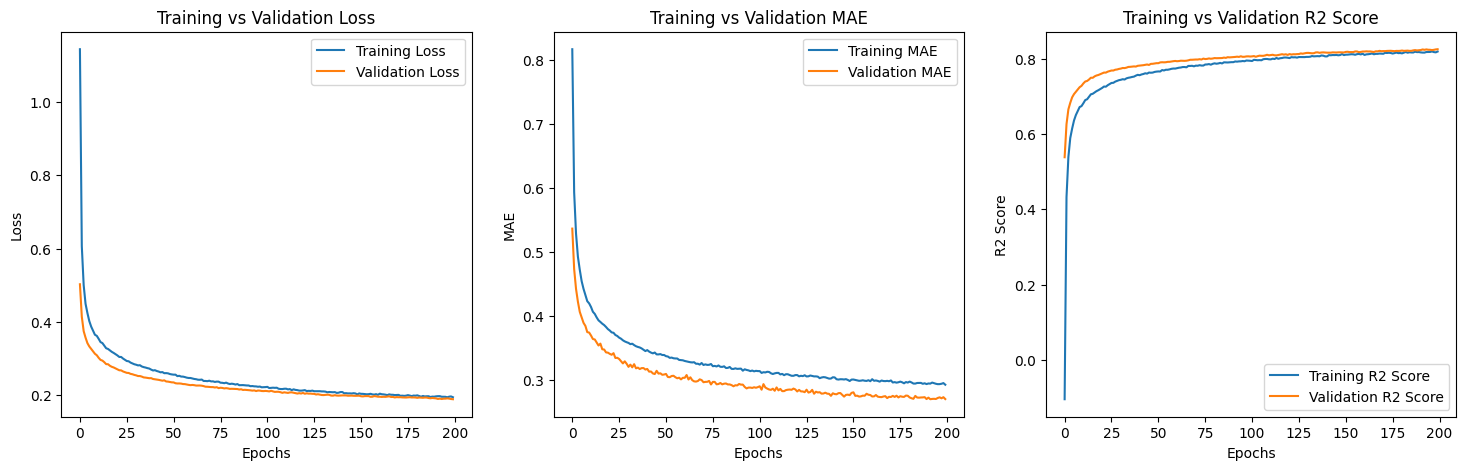

In [29]:
plot_overfitting(history)

## 8. Find Better Hyperparameters


Hyperparameters

In [30]:
LEARNING_RATE = 1e-4
BATCH_SIZE = 64
EPOCHS = 200

Build new model

In [31]:
model_2 = Sequential(
  [
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu', kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dropout(0.1),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dropout(0.0),
    Dense(32, activation='relu', kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dense(1, activation='linear')
  ]
)
model_2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=[
      tf.keras.metrics.MeanAbsoluteError(name='mae'),
      tf.keras.metrics.R2Score(name='r2_score')
    ]
)
# model_2.summary()

Train new model

In [32]:
history = model_2.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.1484 - mae: 0.8209 - r2_score: -0.1600 - val_loss: 0.4001 - val_mae: 0.4909 - val_r2_score: 0.6055
Epoch 2/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.4780 - mae: 0.5379 - r2_score: 0.5212 - val_loss: 0.3411 - val_mae: 0.4436 - val_r2_score: 0.6641
Epoch 3/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4039 - mae: 0.4876 - r2_score: 0.5989 - val_loss: 0.3155 - val_mae: 0.4193 - val_r2_score: 0.6897
Epoch 4/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3704 - mae: 0.4606 - r2_score: 0.6356 - val_loss: 0.2991 - val_mae: 0.4030 - val_r2_score: 0.7060
Epoch 5/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3458 - mae: 0.4403 - r2_score: 0.6587 - val_loss: 0.2861 - val_mae: 0.3904 - val_r2_score: 0.7189
Epoch 6/200
1206/1206 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.3285 - mae: 0.4257 - r2_score: 0.6752 - val_loss: 0.2761 - val_mae: 0.3793 - val_r2_score: 0.7290
Epoch 7/200
1206/120

Evolution

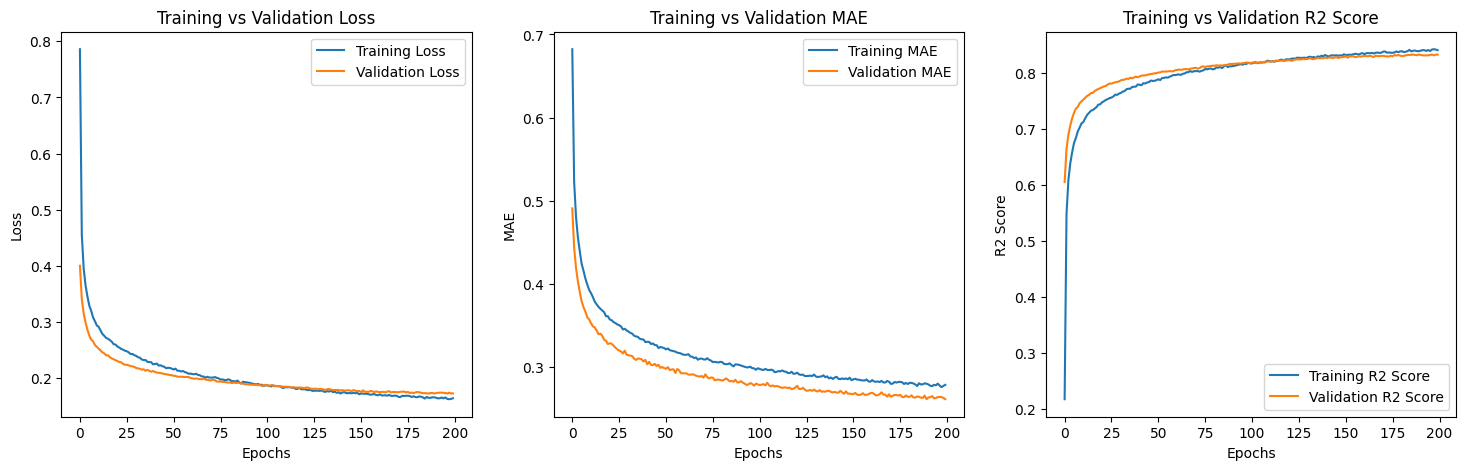

In [33]:
plot_overfitting(history)

## 9. Performance Metrics

In [34]:
print("Model 1 - Metrics")
result = model_1.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {result[0]}, MAE: {result[1]}, R2 Score: {result[2]}")
print("\n")
print("Model 2 - Metrics")
result = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {result[0]}, MAE: {result[1]}, R2 Score: {result[2]}")

Model 1 - Metrics
Loss: 0.18868564069271088, MAE: 0.2703198492527008, R2 Score: 0.8252884745597839


Model 2 - Metrics
Loss: 0.1724025160074234, MAE: 0.26156389713287354, R2 Score: 0.8329626321792603
